In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()



Saving cleaned_april_weather.csv to cleaned_april_weather (2).csv
Saving cleaned_june_weather.csv to cleaned_june_weather (2).csv
Saving cleaned_march_weather.csv to cleaned_march_weather (2).csv
Saving cleaned_may_weather.csv to cleaned_may_weather (2).csv
Saving cleaned_panel_data_ps (1).csv to cleaned_panel_data_ps (1) (2).csv
Saving Soiling(march_july).csv to Soiling(march_july).csv


In [ ]:
panel_df = pd.read_csv("cleaned_panel_data_ps (1).csv")


In [ ]:
panel_df.head()


,Datetime,Voltage,Current,Power,Panel_State
0,10-03-2023 08:00,19.571650,1.339900,26.224054,1
1,10-03-2023 08:00,19.679100,1.342100,26.411320,0
2,10-03-2023 09:00,19.082627,2.104691,40.163032,1
3,10-03-2023 09:00,19.152545,2.144227,41.067410,0
4,10-03-2023 10:00,19.333625,2.229750,43.109150,1


In [ ]:
panel_df['Datetime'] = pd.to_datetime(
    panel_df['Datetime'],
    format='%d-%m-%Y %H:%M'
)


In [ ]:
panel_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3058 entries, 0 to 3057
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Datetime     3058 non-null   datetime64[ns]
 1   Voltage      3058 non-null   float64       
 2   Current      3058 non-null   float64       
 3   Power        3058 non-null   float64       
 4   Panel_State  3058 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 119.6 KB


In [ ]:
weather_march = pd.read_csv("cleaned_march_weather.csv")
weather_april = pd.read_csv("cleaned_april_weather.csv")
weather_may   = pd.read_csv("cleaned_may_weather.csv")
weather_june  = pd.read_csv("cleaned_june_weather.csv")


In [ ]:
weather_df = pd.concat(
    [weather_march, weather_april, weather_may, weather_june],
    ignore_index=True
)


In [ ]:
weather_df = weather_df.drop_duplicates(subset=['Datetime'])


In [ ]:
weather_df.head()
weather_df.tail()


,Datetime,Outdoor Temperature (°C),Feels Like (°C),Dew Point (°C),Wind Speed (m/sec),Wind Gust (m/sec),Max Daily Gust (m/sec),Wind Direction (°),Hourly Rain (mm/hr),Event Rain (mm),Daily Rain (mm),Weekly Rain (mm),Monthly Rain (mm),Yearly Rain (mm),Humidity (%),Ultra-Violet Radiation Index,Solar Radiation (W/m^2),Outdoor Battery,Avg Wind Direction (10 mins) (°),Avg Wind Speed (10 mins) (m/sec)
2971,2023-06-30 19:00:00,33.07,38.28,23.10,0.41,0.62,10.2,251.75,0.0,0.0,0.0,0.0,199.9,199.9,56.08,0.0,0.0,1.0,245.83,0.41
2972,2023-06-30 20:00:00,31.95,37.60,23.76,0.18,0.42,10.2,247.08,0.0,0.0,0.0,0.0,199.9,199.9,62.08,0.0,0.0,1.0,208.83,0.15
2973,2023-06-30 21:00:00,31.42,37.38,24.19,0.38,0.88,10.2,161.00,0.0,0.0,0.0,0.0,199.9,199.9,65.67,0.0,0.0,1.0,146.00,0.42
2974,2023-06-30 22:00:00,30.63,36.74,24.60,0.20,0.71,10.2,146.00,0.0,0.0,0.0,0.0,199.9,199.9,70.42,0.0,0.0,1.0,140.00,0.33
2975,2023-06-30 23:00:00,29.37,35.20,25.03,0.42,0.67,10.2,239.33,0.0,0.0,0.0,0.0,199.9,199.9,77.67,0.0,0.0,1.0,248.25,0.24


In [ ]:
weather_df['Datetime'] = pd.to_datetime(
    weather_df['Datetime']
)


In [ ]:
weather_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2928 entries, 0 to 2975
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Datetime                          2928 non-null   datetime64[ns]
 1   Outdoor Temperature (°C)          2928 non-null   float64       
 2   Feels Like (°C)                   2928 non-null   float64       
 3   Dew Point (°C)                    2928 non-null   float64       
 4   Wind Speed (m/sec)                2928 non-null   float64       
 5   Wind Gust (m/sec)                 2928 non-null   float64       
 6   Max Daily Gust (m/sec)            2928 non-null   float64       
 7   Wind Direction (°)                2928 non-null   float64       
 8   Hourly Rain (mm/hr)               2928 non-null   float64       
 9   Event Rain (mm)                   2928 non-null   float64       
 10  Daily Rain (mm)                   2928 non-null   flo

In [ ]:
import re
weather_df.columns = (
    weather_df.columns
    .str.strip()
    .str.lower()
    .str.replace("Â", "", regex=False)
    .str.replace("°", "deg", regex=False)
    .str.replace("%", "pct", regex=False)
    .str.replace("^2", "2", regex=False)
    .str.replace("^", "", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("-", "_", regex=False)
    .str.replace("__+", "_", regex=True)
)


In [ ]:
weather_df.columns


Index(['datetime', 'outdoor temperature degc', 'feels like degc',
       'dew point degc', 'wind speed m_sec', 'wind gust m_sec',
       'max daily gust m_sec', 'wind direction deg', 'hourly rain mm_hr',
       'event rain mm', 'daily rain mm', 'weekly rain mm', 'monthly rain mm',
       'yearly rain mm', 'humidity pct', 'ultra_violet radiation index',
       'solar radiation w_m2', 'outdoor battery',
       'avg wind direction 10 mins deg', 'avg wind speed 10 mins m_sec'],
      dtype='object')

In [ ]:
panel_df.columns


Index(['Datetime', 'Voltage', 'Current', 'Power', 'Panel_State'], dtype='object')

In [ ]:
weather_df.columns


Index(['datetime', 'outdoor temperature degc', 'feels like degc',
       'dew point degc', 'wind speed m_sec', 'wind gust m_sec',
       'max daily gust m_sec', 'wind direction deg', 'hourly rain mm_hr',
       'event rain mm', 'daily rain mm', 'weekly rain mm', 'monthly rain mm',
       'yearly rain mm', 'humidity pct', 'ultra_violet radiation index',
       'solar radiation w_m2', 'outdoor battery',
       'avg wind direction 10 mins deg', 'avg wind speed 10 mins m_sec'],
      dtype='object')

In [ ]:
weather_df.rename(columns={'datetime': 'Datetime'}, inplace=True)


In [ ]:
weather_df.columns


Index(['Datetime', 'outdoor temperature degc', 'feels like degc',
       'dew point degc', 'wind speed m_sec', 'wind gust m_sec',
       'max daily gust m_sec', 'wind direction deg', 'hourly rain mm_hr',
       'event rain mm', 'daily rain mm', 'weekly rain mm', 'monthly rain mm',
       'yearly rain mm', 'humidity pct', 'ultra_violet radiation index',
       'solar radiation w_m2', 'outdoor battery',
       'avg wind direction 10 mins deg', 'avg wind speed 10 mins m_sec'],
      dtype='object')

In [ ]:
merged_df = pd.merge(
    panel_df,
    weather_df,
    on='Datetime',
    how='left'
)


In [ ]:
print(len(panel_df), len(merged_df))

3058 3058


In [ ]:
merged_df.isna().sum()


,0
Datetime,0
Voltage,0
Current,0
Power,0
Panel_State,0
outdoor temperature degc,0
feels like degc,0
dew point degc,0
wind speed m_sec,0
wind gust m_sec,0


In [ ]:
merged_df[merged_df['Datetime'] == '2023-03-10 08:00:00']


,Datetime,Voltage,Current,Power,Panel_State,outdoor temperature degc,feels like degc,dew point degc,wind speed m_sec,wind gust m_sec,...,daily rain mm,weekly rain mm,monthly rain mm,yearly rain mm,humidity pct,ultra_violet radiation index,solar radiation w_m2,outdoor battery,avg wind direction 10 mins deg,avg wind speed 10 mins m_sec
0,2023-03-10 08:00:00,19.57165,1.3399,26.224054,1,23.97,24.38,19.3,0.69,1.29,...,0.0,0.0,0.0,1063.6,75.33,1.67,224.49,1.0,209.08,0.76
1,2023-03-10 08:00:00,19.67910,1.3421,26.411320,0,23.97,24.38,19.3,0.69,1.29,...,0.0,0.0,0.0,1063.6,75.33,1.67,224.49,1.0,209.08,0.76


In [ ]:
#merging soiling rate

In [ ]:
soiling_df = pd.read_csv("Soiling(march_july).csv")

soiling_df.head()

,Date,soiling rate
0,01-03-2023,15.700717
1,02-03-2023,16.347431
2,03-03-2023,17.102699
3,04-03-2023,17.112651
4,05-03-2023,17.457258


In [ ]:
soiling_df['Date'] = pd.to_datetime(soiling_df['Date'], format='%d-%m-%Y')


In [ ]:
merged_df['Date'] = pd.to_datetime(merged_df['Datetime']).dt.date
merged_df['Date'] = pd.to_datetime(merged_df['Date'])


In [ ]:
final_df = pd.merge(
    merged_df,
    soiling_df[['Date', 'soiling rate']],
    on='Date',
    how='left'
)


In [ ]:
final_df.head()


,Datetime,Voltage,Current,Power,Panel_State,outdoor temperature degc,feels like degc,dew point degc,wind speed m_sec,wind gust m_sec,...,monthly rain mm,yearly rain mm,humidity pct,ultra_violet radiation index,solar radiation w_m2,outdoor battery,avg wind direction 10 mins deg,avg wind speed 10 mins m_sec,Date,soiling rate
0,2023-03-10 08:00:00,19.571650,1.339900,26.224054,1,23.97,24.38,19.30,0.69,1.29,...,0.0,1063.6,75.33,1.67,224.49,1.0,209.08,0.76,2023-03-10,19.419513
1,2023-03-10 08:00:00,19.679100,1.342100,26.411320,0,23.97,24.38,19.30,0.69,1.29,...,0.0,1063.6,75.33,1.67,224.49,1.0,209.08,0.76,2023-03-10,19.419513
2,2023-03-10 09:00:00,19.082627,2.104691,40.163032,1,26.47,27.43,20.32,1.05,1.58,...,0.0,1063.6,69.08,3.08,353.52,1.0,155.42,0.78,2023-03-10,19.419513
3,2023-03-10 09:00:00,19.152545,2.144227,41.067410,0,26.47,27.43,20.32,1.05,1.58,...,0.0,1063.6,69.08,3.08,353.52,1.0,155.42,0.78,2023-03-10,19.419513
4,2023-03-10 10:00:00,19.333625,2.229750,43.109150,1,28.54,30.37,20.18,1.38,2.43,...,0.0,1063.6,60.67,5.67,638.20,1.0,134.75,1.37,2023-03-10,19.419513


In [ ]:
final_df = final_df.drop(columns=['Date'])


In [ ]:
final_df.head()


,Datetime,Voltage,Current,Power,Panel_State,outdoor temperature degc,feels like degc,dew point degc,wind speed m_sec,wind gust m_sec,...,weekly rain mm,monthly rain mm,yearly rain mm,humidity pct,ultra_violet radiation index,solar radiation w_m2,outdoor battery,avg wind direction 10 mins deg,avg wind speed 10 mins m_sec,soiling rate
0,2023-03-10 08:00:00,19.571650,1.339900,26.224054,1,23.97,24.38,19.30,0.69,1.29,...,0.0,0.0,1063.6,75.33,1.67,224.49,1.0,209.08,0.76,19.419513
1,2023-03-10 08:00:00,19.679100,1.342100,26.411320,0,23.97,24.38,19.30,0.69,1.29,...,0.0,0.0,1063.6,75.33,1.67,224.49,1.0,209.08,0.76,19.419513
2,2023-03-10 09:00:00,19.082627,2.104691,40.163032,1,26.47,27.43,20.32,1.05,1.58,...,0.0,0.0,1063.6,69.08,3.08,353.52,1.0,155.42,0.78,19.419513
3,2023-03-10 09:00:00,19.152545,2.144227,41.067410,0,26.47,27.43,20.32,1.05,1.58,...,0.0,0.0,1063.6,69.08,3.08,353.52,1.0,155.42,0.78,19.419513
4,2023-03-10 10:00:00,19.333625,2.229750,43.109150,1,28.54,30.37,20.18,1.38,2.43,...,0.0,0.0,1063.6,60.67,5.67,638.20,1.0,134.75,1.37,19.419513


In [ ]:
final_df.to_csv("panel_weather_merged.csv", index=False)


In [ ]:
files.download("panel_weather_merged.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **EDA**


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


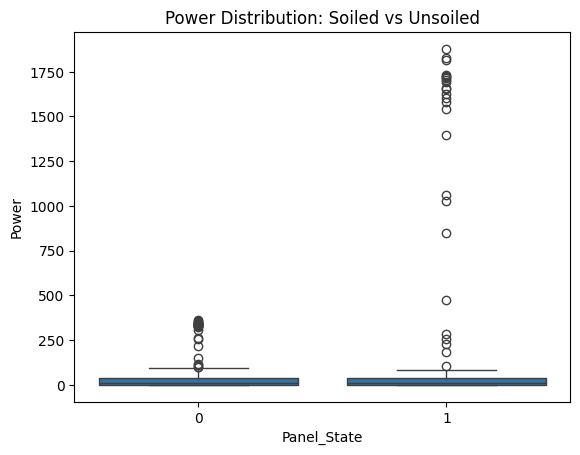

In [ ]:

#Power Distribution: Soiled vs Unsoiled
sns.boxplot(x='Panel_State', y='Power', data=merged_df)
plt.title("Power Distribution: Soiled vs Unsoiled")
plt.show()


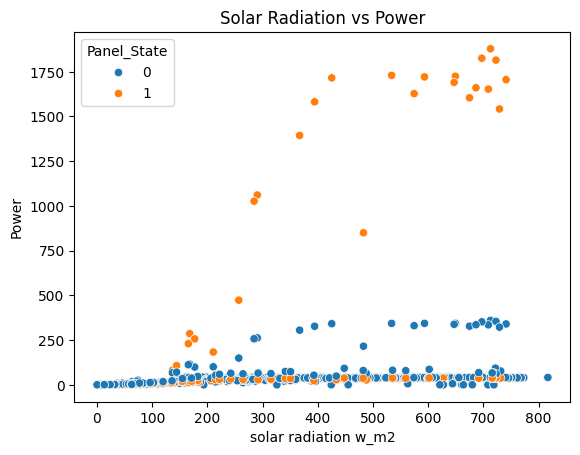

In [ ]:
#Solar Radiation vs Power
sns.scatterplot(
    x='solar radiation w_m2',
    y='Power',
    hue='Panel_State',
    data=merged_df
)
plt.title("Solar Radiation vs Power")
plt.show()

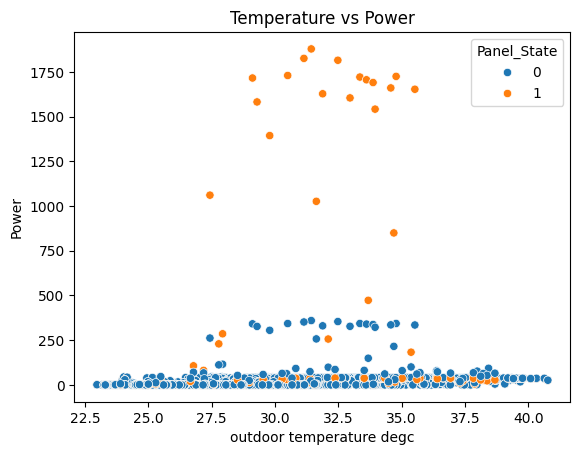

In [ ]:
#Power vs Temperature
sns.scatterplot(
    x='outdoor temperature degc',
    y='Power',
    hue='Panel_State',
    data=merged_df
)
plt.title("Temperature vs Power")
plt.show()

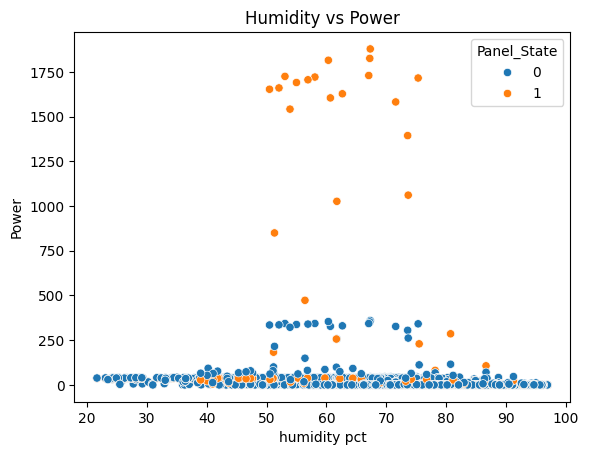

In [ ]:
#Humidity vs Power
sns.scatterplot(
    x='humidity pct',
    y='Power',
    hue='Panel_State',
    data=merged_df
)
plt.title("Humidity vs Power")
plt.show()

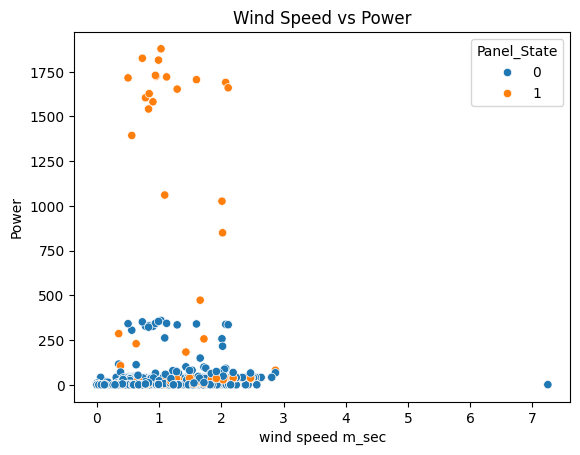

In [ ]:
#Wind Speed vs Power
sns.scatterplot(
    x='wind speed m_sec',
    y='Power',
    hue='Panel_State',
    data=merged_df
)
plt.title("Wind Speed vs Power")
plt.show()

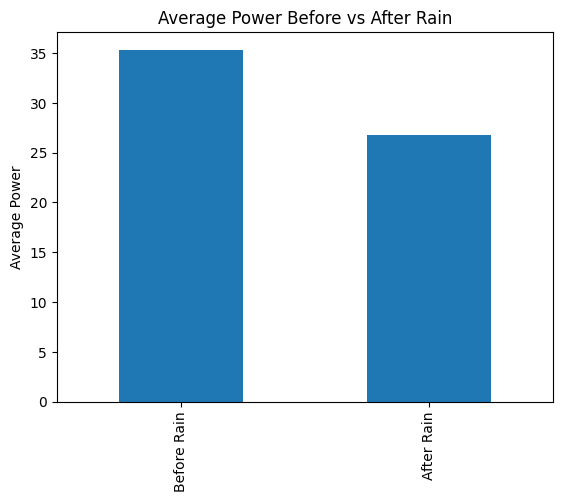

In [ ]:
#Rain Cleaning Effect (Before vs After Rain)
# Identify rainy days
# Convert Datetime column properly
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])

# Create date column
merged_df['date'] = merged_df['Datetime'].dt.date

# Identify rainy days
rain_days = merged_df.loc[merged_df['daily rain mm'] > 0, 'date'].unique()

before_list = []
after_list = []

for day in rain_days:
    prev_day = pd.to_datetime(day) - pd.Timedelta(days=1)
    next_day = pd.to_datetime(day) + pd.Timedelta(days=1)

    before_power = merged_df.loc[
        merged_df['date'] == prev_day.date(), 'Power'
    ].mean()

    after_power = merged_df.loc[
        merged_df['date'] == next_day.date(), 'Power'
    ].mean()

    before_list.append(before_power)
    after_list.append(after_power)

rain_effect_df = pd.DataFrame({
    'Before Rain': before_list,
    'After Rain': after_list
})

rain_effect_df.mean().plot(kind='bar')
plt.title("Average Power Before vs After Rain")
plt.ylabel("Average Power")
plt.show()


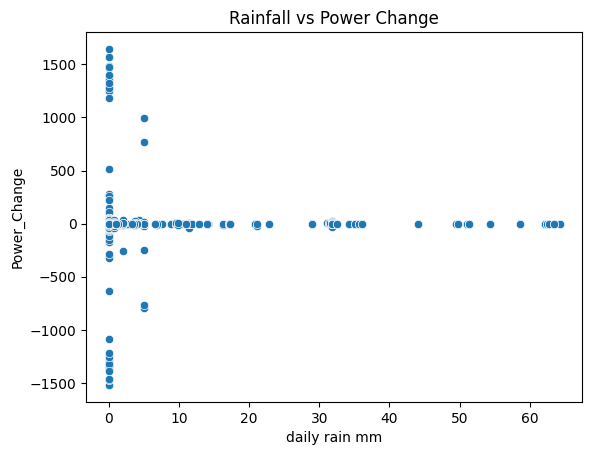

In [ ]:
#Rain vs Power Change
merged_df['Power_Change'] = merged_df['Power'].diff()

sns.scatterplot(
    x='daily rain mm',
    y='Power_Change',
    data=merged_df
)
plt.title("Rainfall vs Power Change")
plt.show()

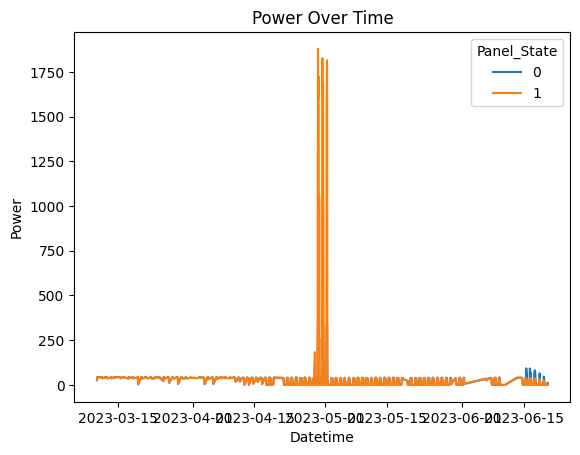

In [ ]:
#Power Over Time
sns.lineplot(
    x='Datetime',
    y='Power',
    hue='Panel_State',
    data=merged_df
)
plt.title("Power Over Time")
plt.show()

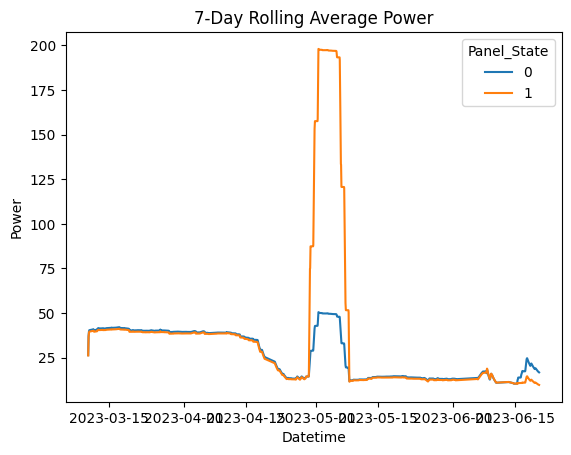

In [ ]:
#7-Day Rolling Average Power
merged_df.set_index('Datetime', inplace=True)

rolling_power = merged_df.groupby('Panel_State')['Power'].rolling('7D').mean().reset_index()

sns.lineplot(
    x='Datetime',
    y='Power',
    hue='Panel_State',
    data=rolling_power
)
plt.title("7-Day Rolling Average Power")
plt.show()

merged_df.reset_index(inplace=True)


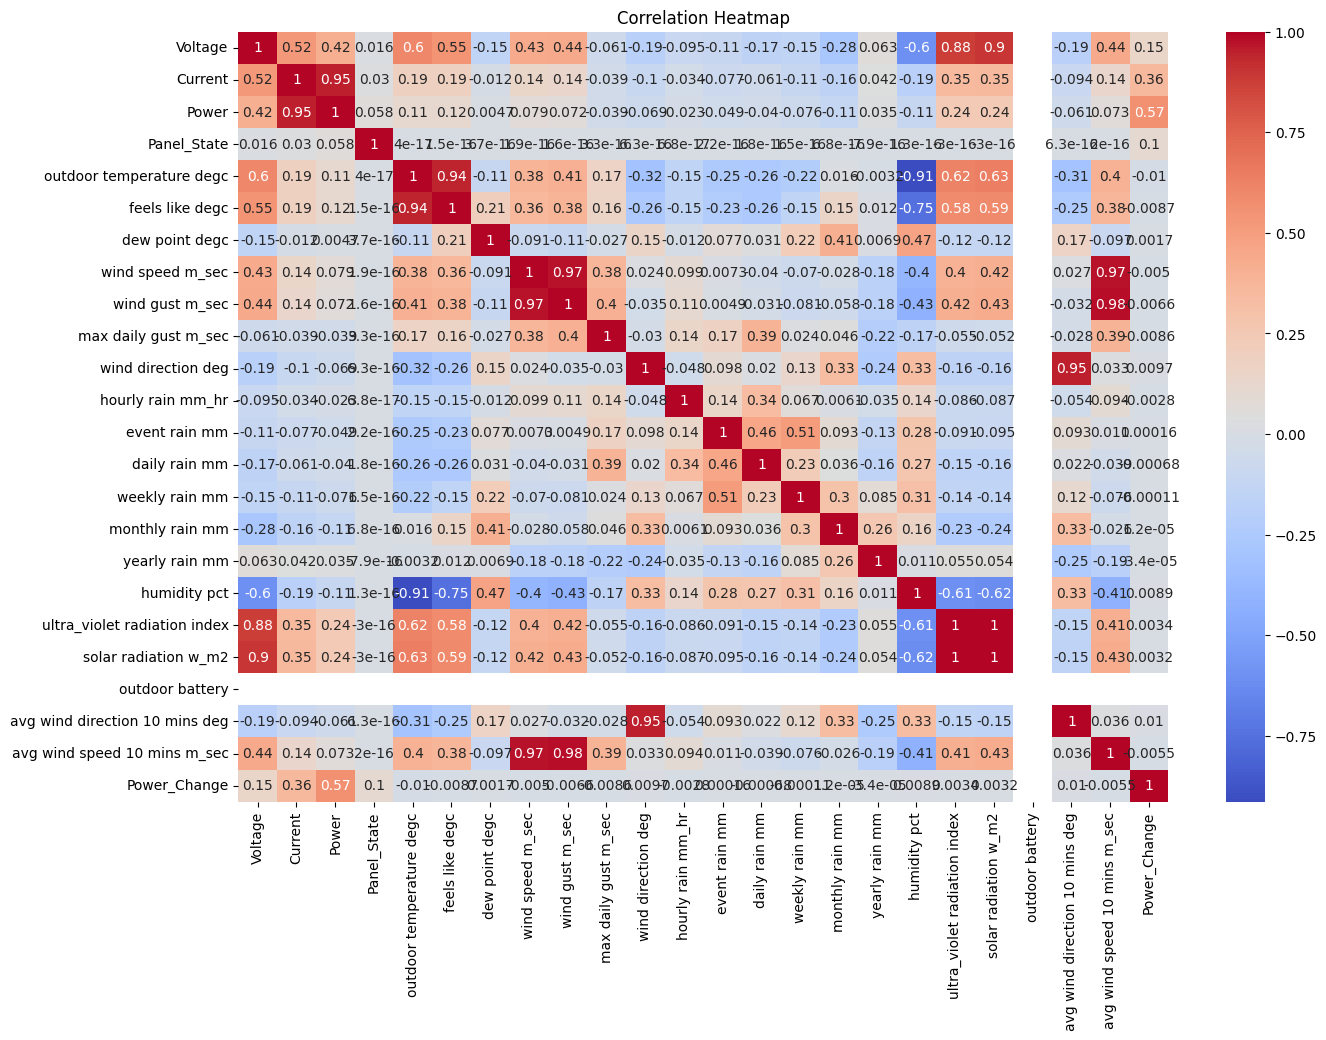

In [ ]:
#Correlation Heatmap
numeric_cols = merged_df.select_dtypes(include=[np.number])

plt.figure(figsize=(15,10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

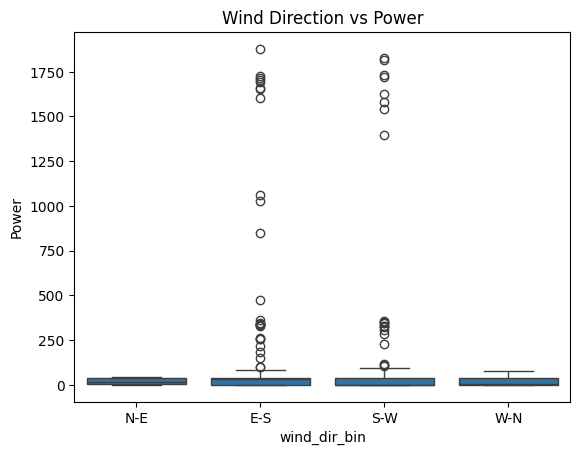

In [ ]:
#Wind Direction Analysis -- need to change
merged_df['wind_dir_bin'] = pd.cut(
    merged_df['wind direction deg'],
    bins=[0,90,180,270,360],
    labels=['N-E','E-S','S-W','W-N']
)

sns.boxplot(x='wind_dir_bin', y='Power', data=merged_df)
plt.title("Wind Direction vs Power")
plt.show()


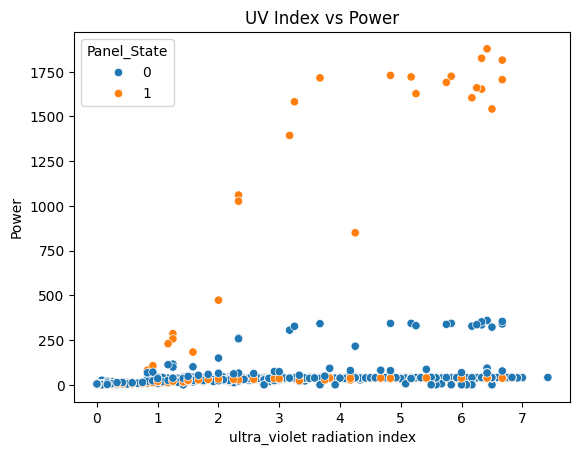

In [ ]:
#UV Index vs Power
sns.scatterplot(
    x='ultra_violet radiation index',
    y='Power',
    hue='Panel_State',
    data=merged_df
)
plt.title("UV Index vs Power")
plt.show()

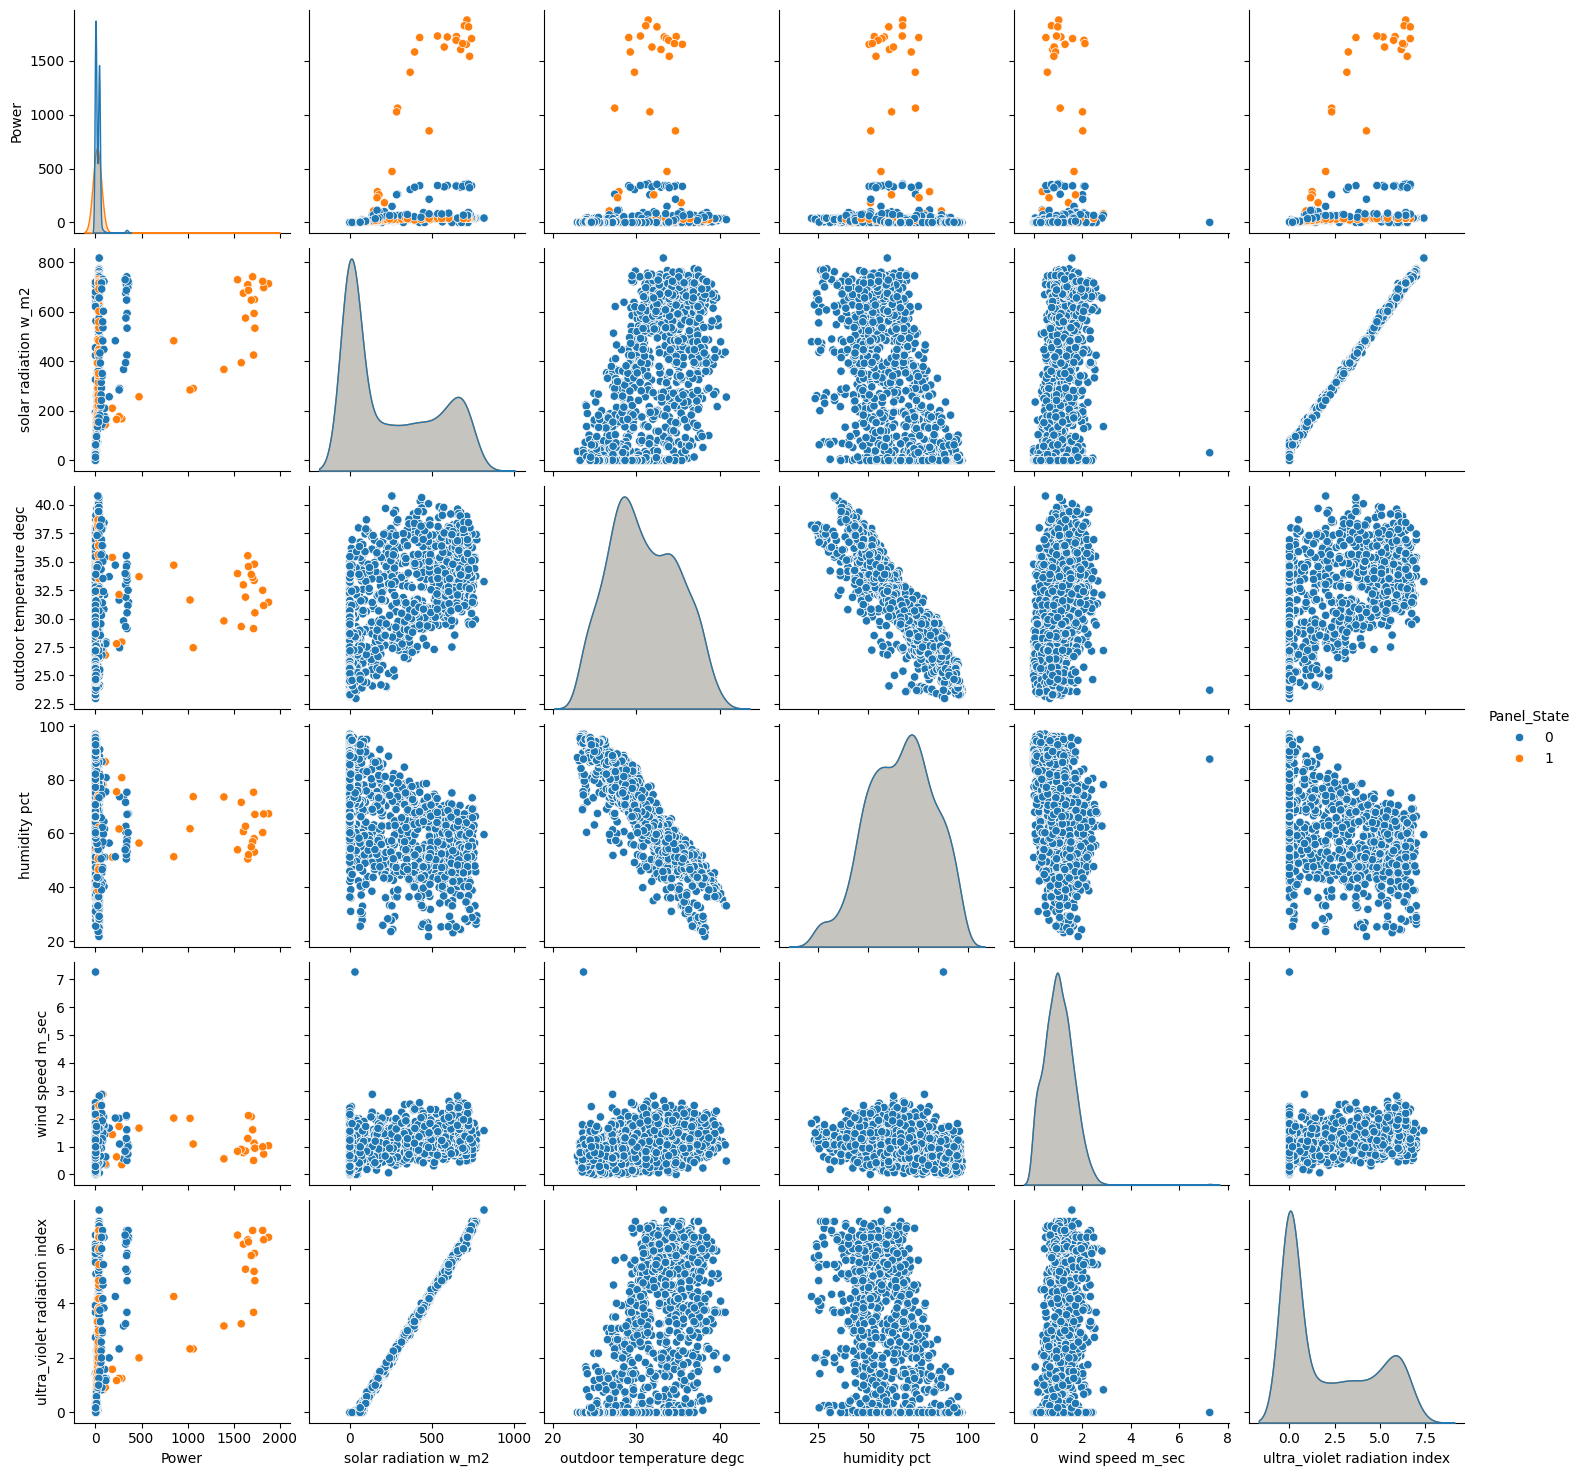

In [ ]:
#Pairplot (Selective Features)
selected_cols = [
    'Power',
    'solar radiation w_m2',
    'outdoor temperature degc',
    'humidity pct',
    'wind speed m_sec',
    'ultra_violet radiation index',
    'Panel_State'
]

sns.pairplot(merged_df[selected_cols], hue='Panel_State')
plt.show()

In [ ]:
# Ensure Datetime is datetime type
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])

# Create month column
merged_df['Month'] = merged_df['Datetime'].dt.month


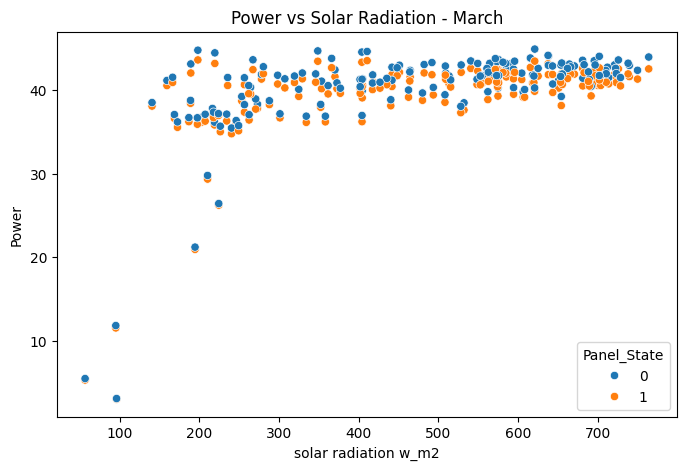

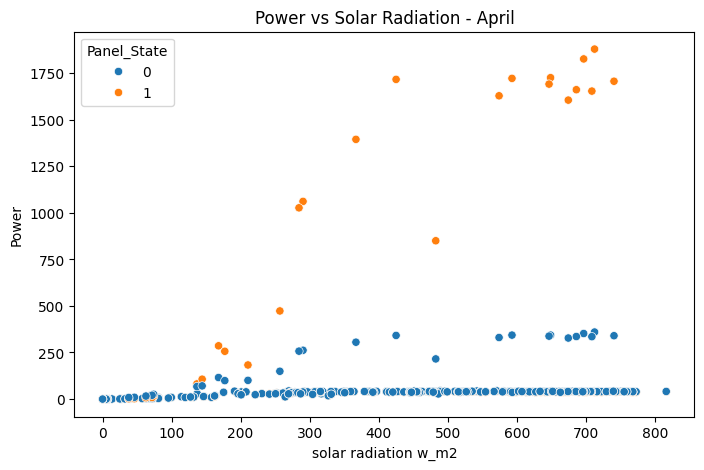

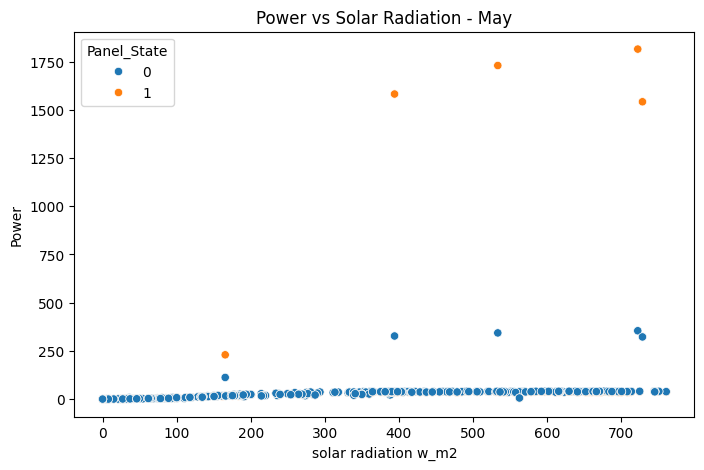

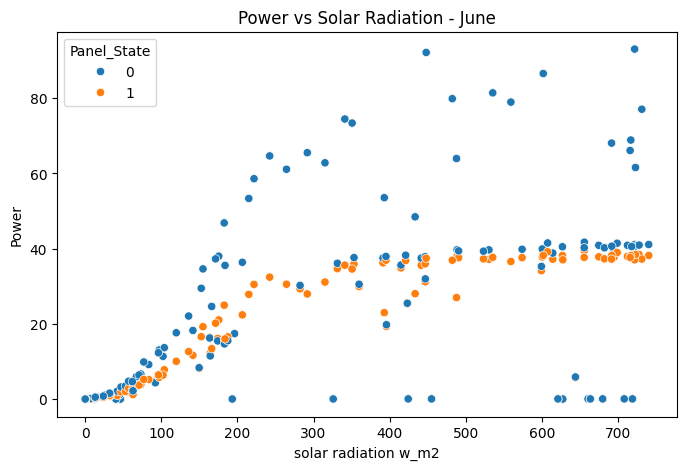

In [ ]:
months = [3, 4, 5, 6]
month_names = ['March', 'April', 'May', 'June']

for m, name in zip(months, month_names):
    plt.figure(figsize=(8,5))

    data = merged_df[merged_df['Month'] == m]

    sns.scatterplot(
        x='solar radiation w_m2',
        y='Power',
        hue='Panel_State',
        data=data
    )

    plt.title(f"Power vs Solar Radiation - {name}")
    plt.show()


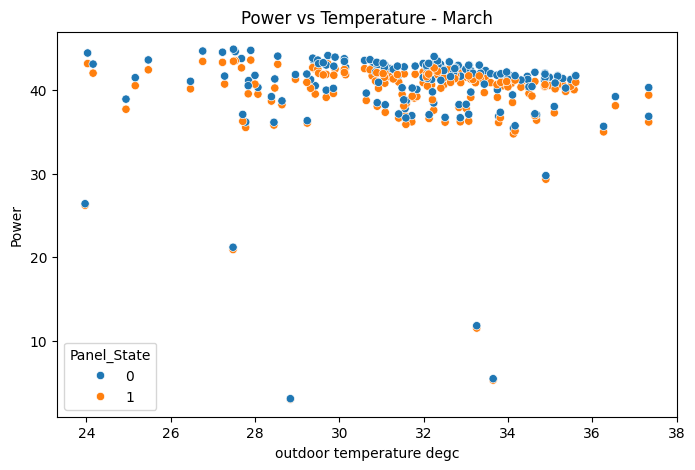

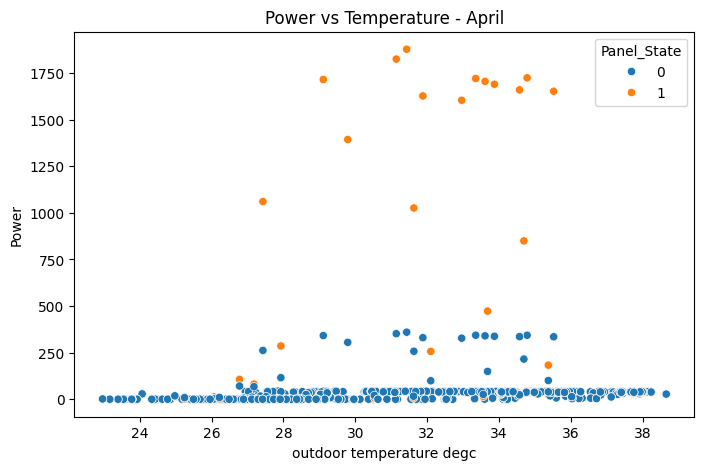

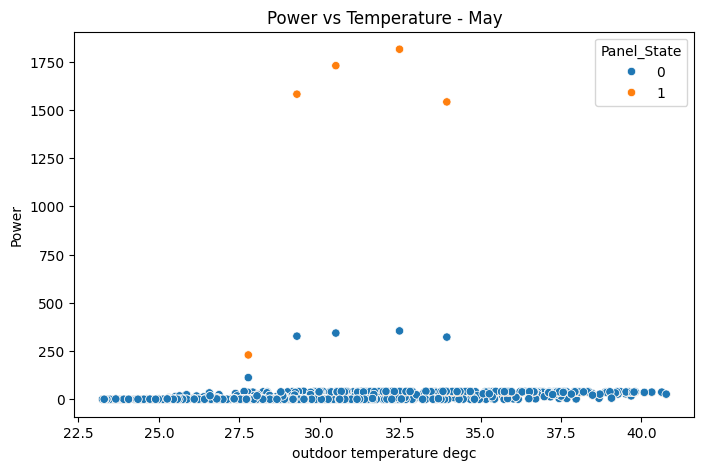

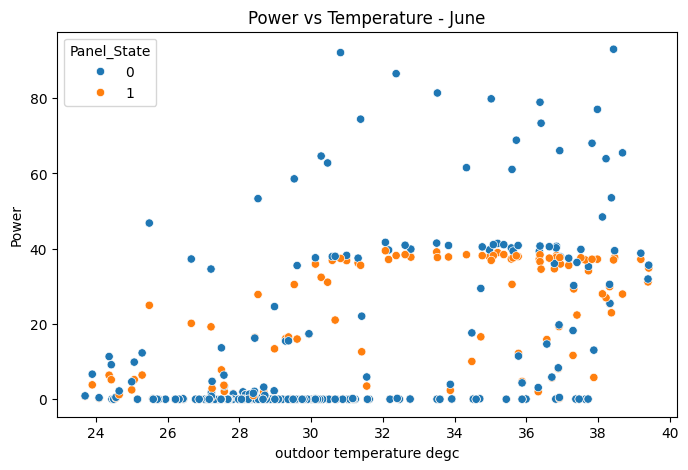

In [ ]:
#Power vs Temperature (Month-wise)
for m, name in zip(months, month_names):
    plt.figure(figsize=(8,5))

    data = merged_df[merged_df['Month'] == m]

    sns.scatterplot(
        x='outdoor temperature degc',
        y='Power',
        hue='Panel_State',
        data=data
    )

    plt.title(f"Power vs Temperature - {name}")
    plt.show()

In [ ]:
# Make sure Datetime is datetime type
merged_df['Datetime'] = pd.to_datetime(merged_df['Datetime'])

# Create Month number
merged_df['Month'] = merged_df['Datetime'].dt.month

# Create Month Name
merged_df['Month_Name'] = merged_df['Datetime'].dt.strftime('%B')


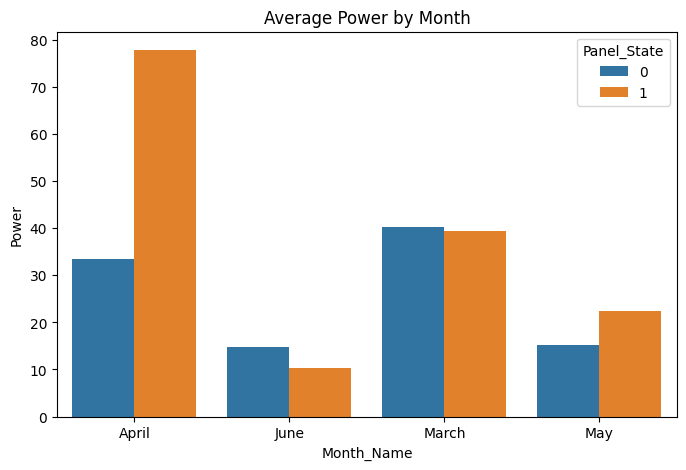

In [ ]:
#Monthly Average Power Trend
monthly_avg = merged_df.groupby(['Month_Name','Panel_State'])['Power'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    x='Month_Name',
    y='Power',
    hue='Panel_State',
    data=monthly_avg
)
plt.title("Average Power by Month")
plt.show()

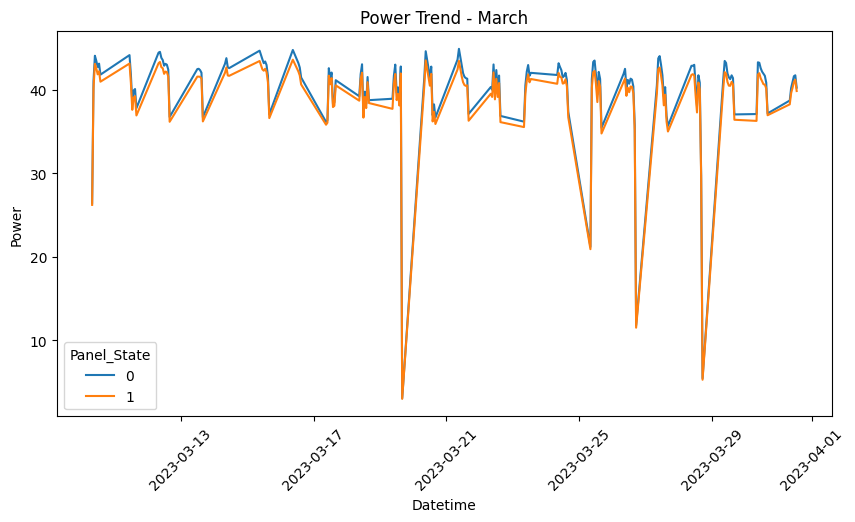

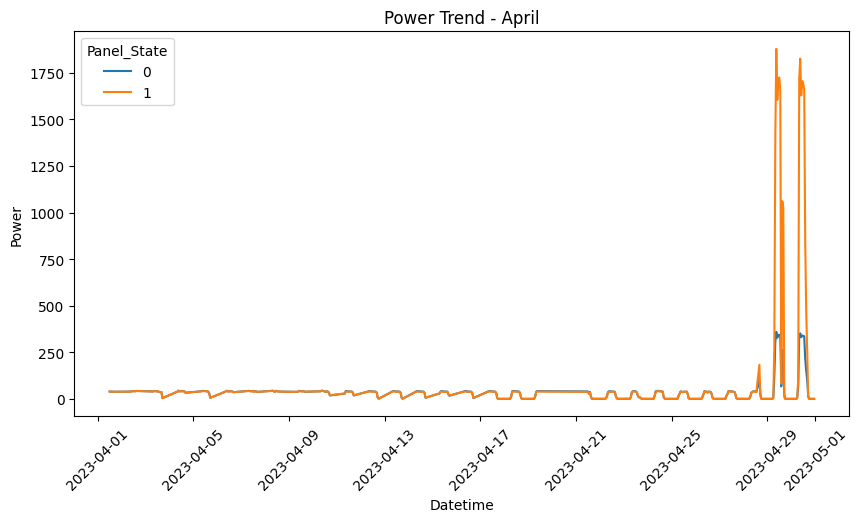

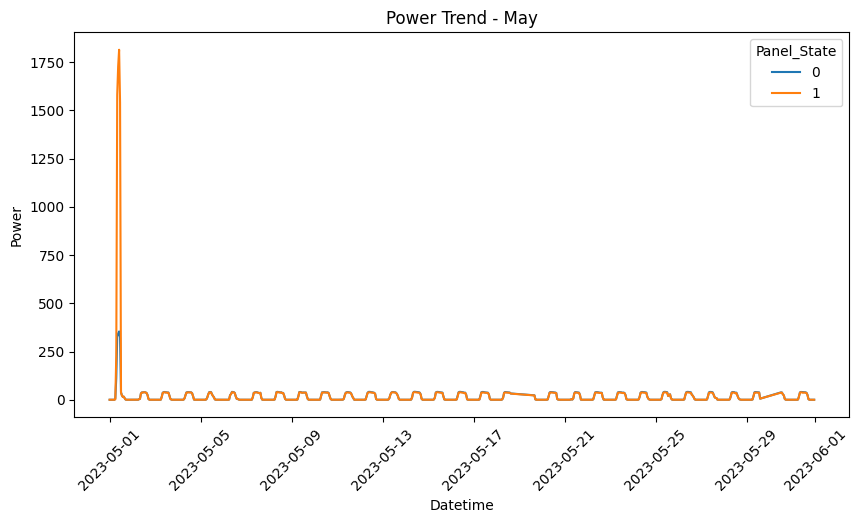

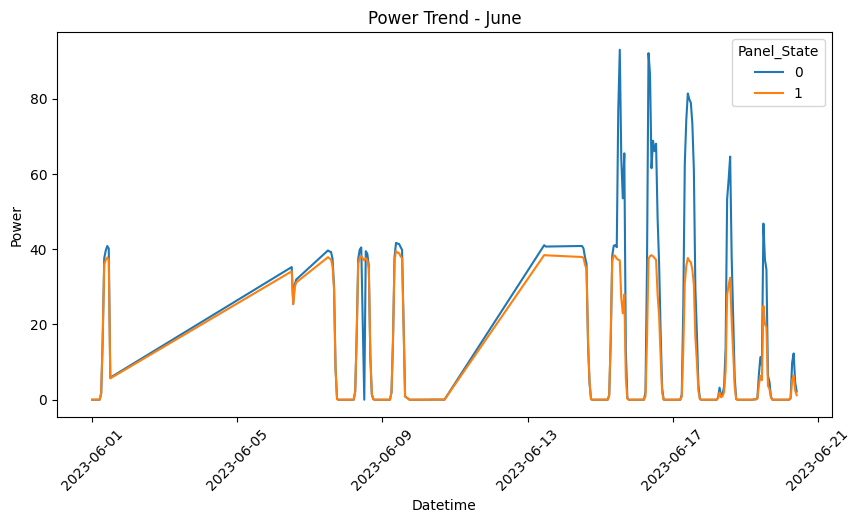

In [ ]:
#Monthly Time-Series Plot
for m, name in zip(months, month_names):
    plt.figure(figsize=(10,5))

    data = merged_df[merged_df['Month'] == m]

    sns.lineplot(
        x='Datetime',
        y='Power',
        hue='Panel_State',
        data=data
    )

    plt.title(f"Power Trend - {name}")
    plt.xticks(rotation=45)
    plt.show()

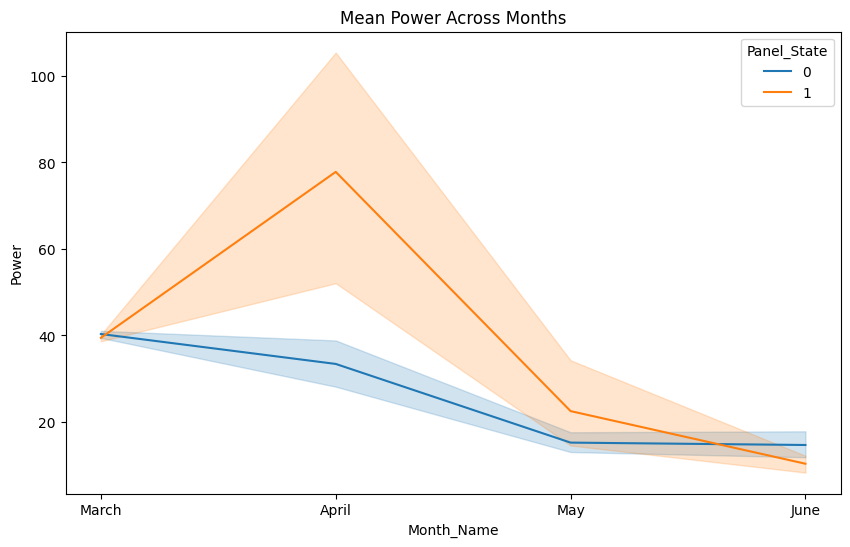

In [ ]:
plt.figure(figsize=(10,6))
sns.lineplot(
    x='Month_Name',
    y='Power',
    hue='Panel_State',
    data=merged_df,
    estimator='mean'
)
plt.title("Mean Power Across Months")
plt.show()
